In [1]:
%pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from urllib.error import URLError

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'

print(f"Attempting to load dataset from URL: {url}")

try:
    df = pd.read_excel(url, engine='openpyxl')
    
    print("\nDataset loaded successfully!")
    
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
    
    print("\nDataFrame Info:")
    df.info()

except URLError as e:
    print(f"\nError: Could not retrieve the file from the URL.")
    print(f"Reason: {e.reason}")
    print("Please check your internet connection or if the URL is still valid.")

except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")
    print("This might be due to a change in the file format or a library issue.")

print("Data loaded successfully. Here are the first 5 rows:")
print(df.head())
print("\nData Information:")
df.info()

Attempting to load dataset from URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

Dataset loaded successfully!

First 5 rows of the dataset:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

DataFr

In [3]:
# Step 2: Data Cleaning and Preprocessing

print("\n--- Starting Data Cleaning ---")

print("\nMissing values per column:")
print(df.isnull().sum())

df.dropna(subset=['CustomerID'], inplace=True)
print(f"\nShape of data after dropping rows with missing CustomerID: {df.shape}")

df.drop_duplicates(inplace=True)
print(f"Shape of data after dropping duplicates: {df.shape}")

df = df[df['Quantity'] > 0]
print(f"Shape of data after removing returns: {df.shape}")

df['CustomerID'] = df['CustomerID'].astype(int)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("\n--- Data Cleaning Complete ---")
print("\nCleaned Data Information:")
df.info()
print("\nSummary statistics of the cleaned data:")
print(df.describe())


--- Starting Data Cleaning ---

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Shape of data after dropping rows with missing CustomerID: (406829, 8)
Shape of data after dropping duplicates: (401604, 8)
Shape of data after removing returns: (392732, 8)

--- Data Cleaning Complete ---

Cleaned Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   Custome


--- Starting Exploratory Data Analysis ---


C:\Users\Shaarukesh\AppData\Local\Temp\ipykernel_3076\3152182587.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')


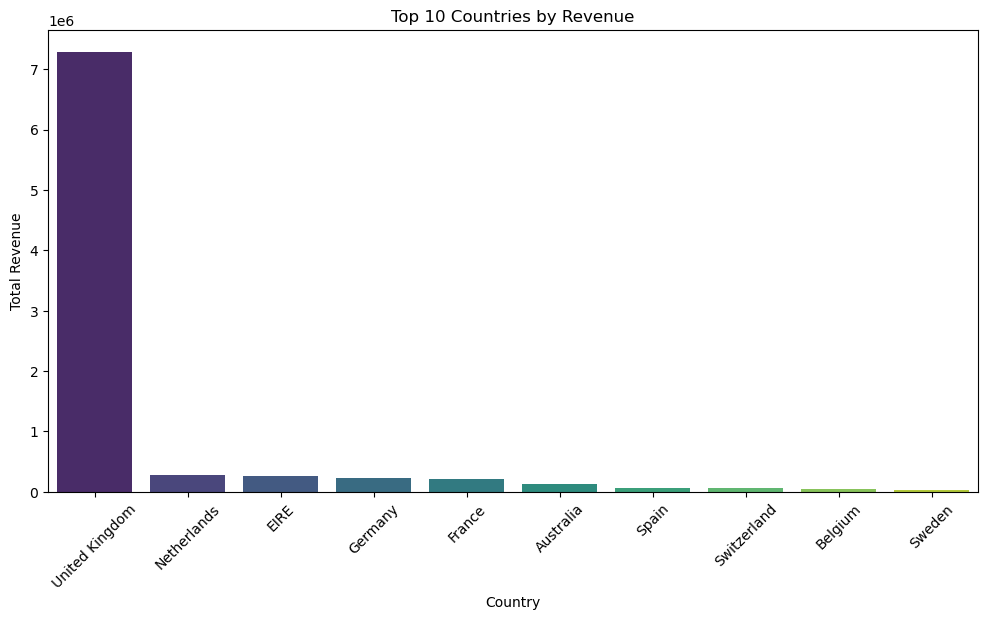

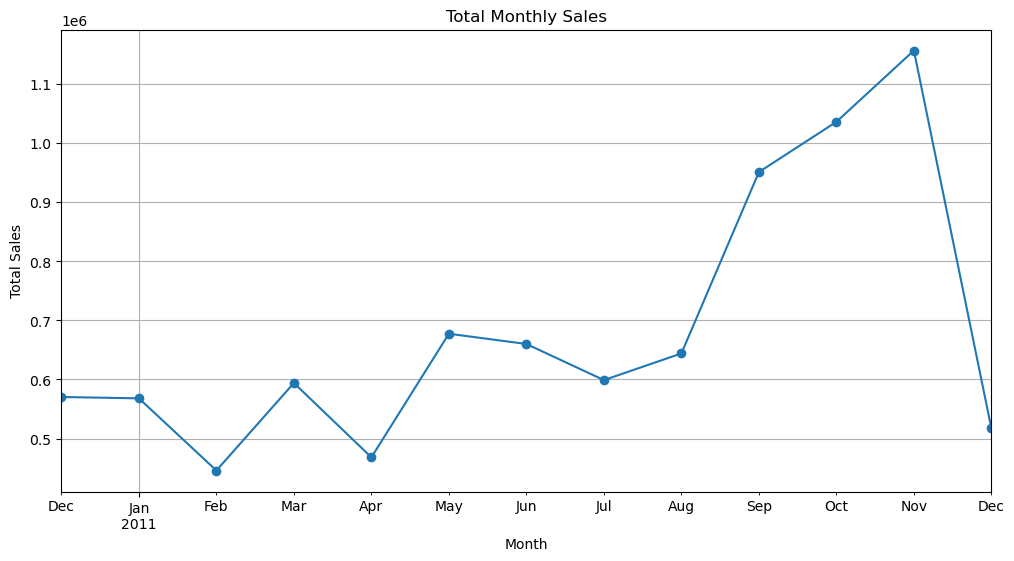

In [4]:
# Step 3: Exploratory Data Analysis (EDA)

print("\n--- Starting Exploratory Data Analysis ---")

# a. Top 10 countries by revenue
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

# b. Sales over time (monthly)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('InvoiceMonth')['TotalPrice'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp() 

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Total Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [5]:
# Step 4: RFM (Recency, Frequency, Monetary) Feature Engineering

print("\n--- Calculating RFM Metrics ---")

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot Date: {snapshot_date}")

# Calculate RFM values for each customer
rfm_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days,
    'InvoiceNo': 'nunique',                                       
    'TotalPrice': 'sum'                                          
})

rfm_df.rename(columns={'InvoiceDate': 'Recency',
                       'InvoiceNo': 'Frequency',
                       'TotalPrice': 'MonetaryValue'}, inplace=True)

print("\nRFM DataFrame (first 5 rows):")
print(rfm_df.head())


--- Calculating RFM Metrics ---
Snapshot Date: 2011-12-10 12:50:00

RFM DataFrame (first 5 rows):
            Recency  Frequency  MonetaryValue
CustomerID                                   
12346           326          1       77183.60
12347             2          7        4310.00
12348            75          4        1797.24
12349            19          1        1757.55
12350           310          1         334.40


In [10]:
# Step 5: Preprocessing RFM Data for Clustering

# Check the skewness of RFM values
print("\nSkewness of RFM features:")
print(rfm_df.skew())

# Apply log transformation to reduce skewness
rfm_log = np.log1p(rfm_df)

print("\nSkewness after log transformation:")
print(rfm_log.skew())

# Scale the log-transformed data using StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert the scaled array back to a DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm_df.index, columns=rfm_df.columns)

print("\nScaled RFM DataFrame (first 5 rows):")
print(rfm_scaled_df.head(10))



Skewness of RFM features:
Recency           1.246357
Frequency        12.100028
MonetaryValue    19.341403
Cluster          -0.424942
dtype: float64

Skewness after log transformation:
Recency         -0.378677
Frequency        1.208917
MonetaryValue    0.363728
Cluster         -0.866765
dtype: float64

Scaled RFM DataFrame (first 5 rows):
             Recency  Frequency  MonetaryValue   Cluster
CustomerID                                              
12346       1.462236  -0.955013       3.697687  0.349179
12347      -2.038611   1.074523       1.411820 -0.443930
12348       0.373310   0.386437       0.719046  0.349179
12349      -0.622914  -0.955013       0.701362 -1.799758
12350       1.424800  -0.955013      -0.611449  0.911898
12352      -0.163841   1.246957       0.982329  0.349179
12353       1.113782  -0.955013      -1.653757  0.911898
12354       1.209321  -0.955013       0.315377  0.911898
12355       1.149323  -0.955013      -0.360464  0.911898
12356      -0.486860   0.05975


--- Starting K-Means Clustering ---


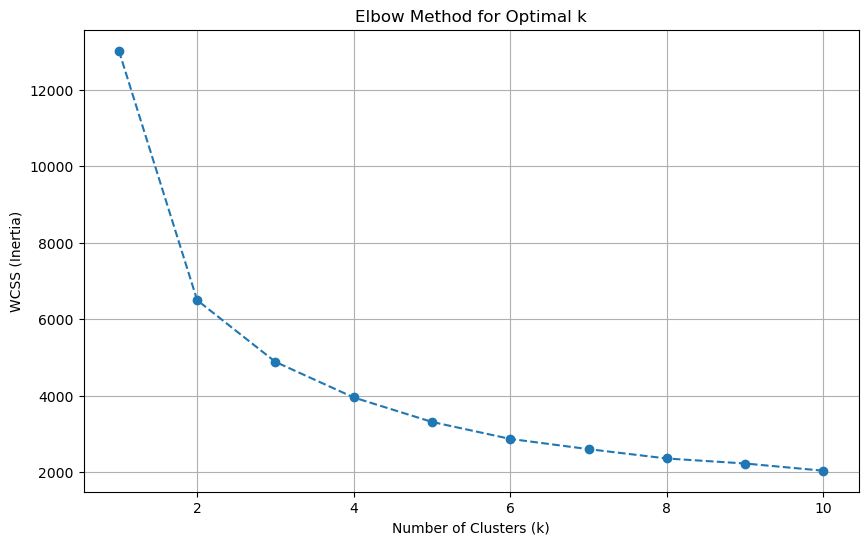


Selected optimal number of clusters: 4

RFM DataFrame with Cluster Labels (first 5 rows):
            Recency  Frequency  MonetaryValue  Cluster
CustomerID                                            
12346           326          1       77183.60        2
12347             2          7        4310.00        1
12348            75          4        1797.24        2
12349            19          1        1757.55        0
12350           310          1         334.40        3


In [7]:
# Step 6: K-Means Clustering

print("\n--- Starting K-Means Clustering ---")

wcss = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss[k] = kmeans.inertia_

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(list(wcss.keys()), list(wcss.values()), marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

optimal_k = 4
print(f"\nSelected optimal number of clusters: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init='auto', random_state=42)
cluster_labels = kmeans.fit_predict(rfm_scaled_df)

rfm_df['Cluster'] = cluster_labels
print("\nRFM DataFrame with Cluster Labels (first 5 rows):")
print(rfm_df.head())


--- Analyzing Customer Segments ---

Mean RFM values for each cluster:
         Recency  Frequency  MonetaryValue
Cluster                                   
0          19.13       2.07         529.47
1          12.11      13.56        7942.68
2          71.13       4.05        1772.05
3         185.66       1.32         337.41


C:\Users\Shaarukesh\AppData\Local\Temp\ipykernel_3076\3761748045.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=rfm_df, palette='viridis')


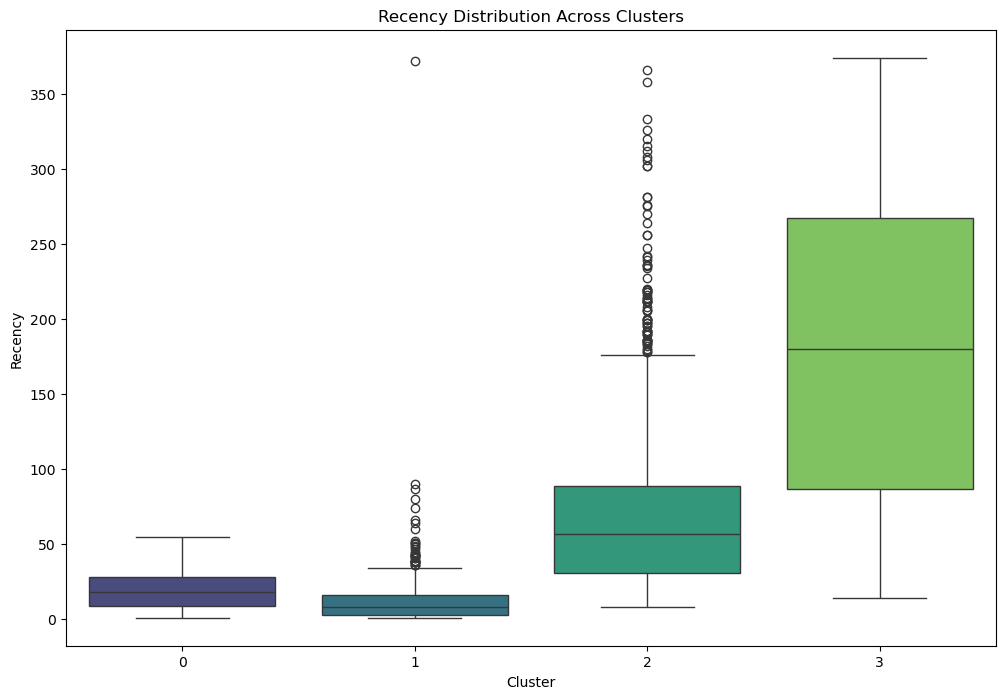

C:\Users\Shaarukesh\AppData\Local\Temp\ipykernel_3076\3761748045.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=rfm_df, palette='viridis')


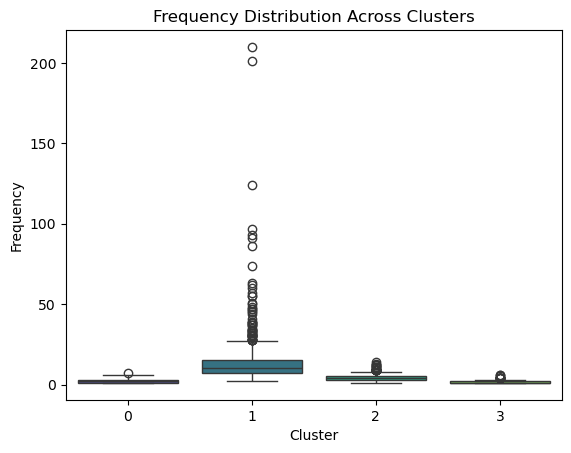

C:\Users\Shaarukesh\AppData\Local\Temp\ipykernel_3076\3761748045.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=rfm_df, palette='viridis')


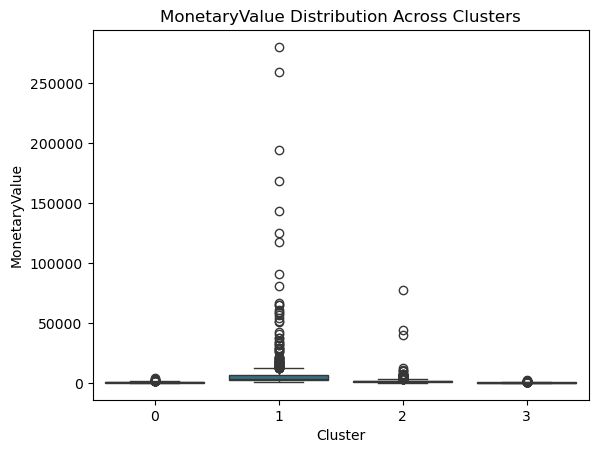

In [8]:
# Step 7: Segment Analysis and Interpretation

print("\n--- Analyzing Customer Segments ---")

# Calculate the mean RFM values for each cluster
cluster_summary = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean'
}).round(2)

print("\nMean RFM values for each cluster:")
print(cluster_summary)

# Visualize the segments
plt.figure(figsize=(12, 8))
for feature in ['Recency', 'Frequency', 'MonetaryValue']:
    sns.boxplot(x='Cluster', y=feature, data=rfm_df, palette='viridis')
    plt.title(f'{feature} Distribution Across Clusters')
    plt.show()

In [9]:
# Step 8: Actionable Recommendations

print("\n--- Segment Interpretation and Business Recommendations ---")

# To make this consistent, let's sort the summary by a key metric, e.g., MonetaryValue
cluster_summary = cluster_summary.sort_values(by='MonetaryValue', ascending=False)
print("\nSorted Cluster Summary:")
print(cluster_summary)

print("\nCustomer Personas & Recommendations:")
print("--------------------------------------------------")
print("Segment 1: Champions / Top Customers")
print("Profile: Low Recency, High Frequency, High Monetary. These are your best and most loyal customers.")
print("Recommendations:")
print("- Reward them with loyalty programs and exclusive offers.")
print("- Engage them for reviews and testimonials.")
print("- Grant early access to new products.")

print("\nSegment 2: Loyal / Promising Customers")
print("Profile: Moderate on all RFM metrics. They are consistent but have room to grow.")
print("Recommendations:")
print("- Nurture them with personalized marketing.")
print("- Offer bundle deals or cross-sell related products.")
print("- Encourage them to join the loyalty program.")

print("\nSegment 3: At-Risk / Needs Attention")
print("Profile: High Recency (haven't purchased in a while), but may have been frequent/valuable in the past.")
print("Recommendations:")
print("- Launch re-engagement campaigns with special discounts ('We miss you!').")
print("- Send personalized reminders about products they've viewed.")
print("- Solicit feedback to understand why they haven't returned.")

print("\nSegment 4: New / Lost Customers")
print("Profile: High Recency, Low Frequency, Low Monetary. Could be new customers or those who have churned.")
print("Recommendations:")
print("- For new customers: Provide a smooth onboarding experience and a welcome offer for their next purchase.")
print("- For lost customers: Consider if they are worth re-engaging or if marketing efforts are better spent elsewhere.")


--- Segment Interpretation and Business Recommendations ---

Sorted Cluster Summary:
         Recency  Frequency  MonetaryValue
Cluster                                   
1          12.11      13.56        7942.68
2          71.13       4.05        1772.05
0          19.13       2.07         529.47
3         185.66       1.32         337.41

Customer Personas & Recommendations:
--------------------------------------------------
Segment 1: Champions / Top Customers
Profile: Low Recency, High Frequency, High Monetary. These are your best and most loyal customers.
Recommendations:
- Reward them with loyalty programs and exclusive offers.
- Engage them for reviews and testimonials.
- Grant early access to new products.

Segment 2: Loyal / Promising Customers
Profile: Moderate on all RFM metrics. They are consistent but have room to grow.
Recommendations:
- Nurture them with personalized marketing.
- Offer bundle deals or cross-sell related products.
- Encourage them to join the loyalty pr